##### 常數

In [1]:
CAMERA_ID = 0
MODEL = "./models/BlazePose/pose_landmarker_full.task"

#### 套件

In [2]:
import cv2
import matplotlib.pyplot as plt

import time
import numpy as np

In [3]:
from mpl_toolkits.mplot3d.axes3d import Axes, Axes3D
from mediapipe.tasks.python.vision.pose_landmarker import PoseLandmarkerResult

In [4]:
from src.mediapipe_lib.base import (
    PoseLandmarkerLiveStream,
    PoseResult,
    ResultAnalyzer,
    LhcPoseListAnalyzer,
)
from src.draw_template import (
    draw_debug_in_img,
    draw_kpt_position_in_img,
    get_bones_plot_axes,
    get_staggered_angle_axes,
    get_hand_center_to_gravity_axes,
)
from src.utils.plot_painter import (
    set_data_range,
    set_plot_labels,
    plot_to_opencv_img,
    draw_bool_list_line_chart,
    draw_pose_result_line_chart,
)
from src.server_api import get_json_result

#### 忽略警告

In [5]:
import warnings

warnings.filterwarnings("ignore")

#### 函式

##### 設定圖表座標資訊

In [6]:
def set_axes_info(is_3d: bool, ax: Axes | Axes3D) -> Axes | Axes3D:
    """設定圖表座標資訊

    Args:
        is_3d (bool): 是否為 3D 姿勢
        ax (Axes | Axes3D): 圖表座標

    Returns:
        Axes | Axes3D: 圖表座標
    """

    # 設定圖表座標資訊
    if not is_3d:
        set_plot_labels("x", "y", ax=ax)  # 設定標籤
        set_data_range([0, 1], [1, 0], ax=ax)  # 設定資料範圍
    else:
        set_plot_labels("x", "z", "y", ax)  # 設定標籤
        set_data_range([-1, 1], [-1, 1], [0, 2], ax)  # 設定資料範圍

    return ax

##### 繪製分析結果圖表

In [7]:
def draw_result_plot(
    result: PoseLandmarkerResult,
    figsize: tuple[float, float] = (6.4, 4.8),
    is_3d: bool = False,
) -> cv2.typing.MatLike:
    """繪製分析結果圖表

    Args:
        result (PoseLandmarkerResult): 姿勢結果
        figsize (tuple[float, float], optional): 圖表大小. Defaults to (6.4, 4.8).
        is_3d (bool, optional): 是否為 3D 姿勢. Defaults to False.

    Returns:
        cv2.typing.MatLike: 分析結果圖片
    """
    # 建立分析器
    analyzer = ResultAnalyzer(PoseResult(result))

    # 建立圖表q
    fig = plt.figure(figsize=figsize)
    ax: Axes3D = fig.add_subplot(projection="3d")
    ax.view_init(0, 90, 0)

    # 設定圖表座標資訊
    set_axes_info(is_3d, ax)

    # 繪製表格
    if len(result.pose_world_landmarks) > 0:
        ax.set_title(analyzer.get_lhc_label(is_3d), fontsize=40)
        get_bones_plot_axes(result, is_3d=is_3d, ax=ax)
        ax.legend()
    else:
        ax.set_title("NO DATA")

    # 將圖表轉換成圖片格式
    rgb = cv2.cvtColor(plot_to_opencv_img(fig), cv2.COLOR_RGBA2RGB)

    plt.close(fig)  # 關閉圖表

    return rgb

#### 開始測試

In [8]:
cap = cv2.VideoCapture(CAMERA_ID)  # 取得串流資訊
live = PoseLandmarkerLiveStream(MODEL)  # 建立模型串流物件
lhc_analyzer = LhcPoseListAnalyzer()  # LHC 姿勢分析物件

is_3d = True  # 表示為 3D 姿勢

# 串流大小(寬高)
cap_size = (
    int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
    int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
)

# 輸出表格大小
plot_size = (cap_size[0] / 100, cap_size[1] / 100)

# 預設輸出影像畫面
default_out_frame = np.zeros((cap_size[1], cap_size[0], 3), np.uint8)

# 進行串流
while cap.isOpened():
    # 抓取影像
    ret, frame = cap.read()
    if not ret:
        cv2.destroyAllWindows()
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # 進行影像分析
    live.detect_async(frame, int(time.time() * 1000))
    mp_img = live.current_image
    result = live.result
    timestamp = live.current_timestamp_ms

    # 模型是否取得影像畫面
    if mp_img is None:
        mp_img = default_out_frame.copy()
    else:
        mp_img = np.array(mp_img.numpy_view())

    ### 繪製分析結果
    mp_img = draw_kpt_position_in_img(result, mp_img)  # 繪製 2D 關鍵點
    mp_img = draw_debug_in_img(result, mp_img, is_3d)  # 繪製偵錯資訊
    plot_img = draw_result_plot(result, plot_size, is_3d)  # 繪製分析圖表
    # 組合原始圖片和分析圖表
    out_frame = np.concatenate((plot_img, mp_img), axis=1)

    # 如果成功在圖片中取得人體姿勢，則加入結果到 lhc_analyzer 中
    if len(result.pose_landmarks) > 0:
        lhc_analyzer += [result]

    # 調整輸出大小
    w, h, c = out_frame.shape
    out_frame = cv2.resize(out_frame, (int(h * 1.2), int(w * 1.2)))

    # 顯示輸出影像
    cv2.imshow("debug", out_frame)
    if cv2.waitKey(1) == ord("q") or cv2.waitKey(1) == ord("Q"):
        cv2.destroyAllWindows()
        break


live.close()
cap.release()
print("finish")

finish


In [9]:
results = get_json_result(lhc_analyzer)
for key, val in results.items():
    print(key, val, sep="  \t")

extra scores: [3. 3. 0. 0.]
sum of extra scores: 6.0
extra scores: [3. 3. 0. 0.]
sum of extra scores: 6.0
start  	A4
end  	A3
extra 1  	FREQUENTLY_OR_CONSTANTLY
extra 2  	FREQUENTLY_OR_CONSTANTLY
extra 3  	RARELY
extra 4  	RARELY
pose score  	10
extra score  	6.0
total score  	16.0


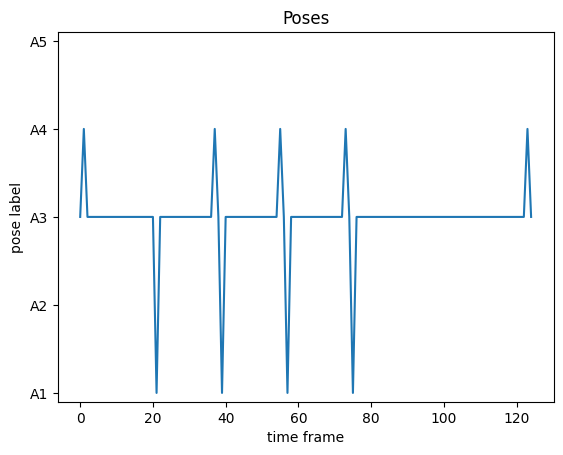

In [10]:
plt.title("Poses")
plt.show(draw_pose_result_line_chart(lhc_analyzer.get_lhc_label_list(is_3d)))

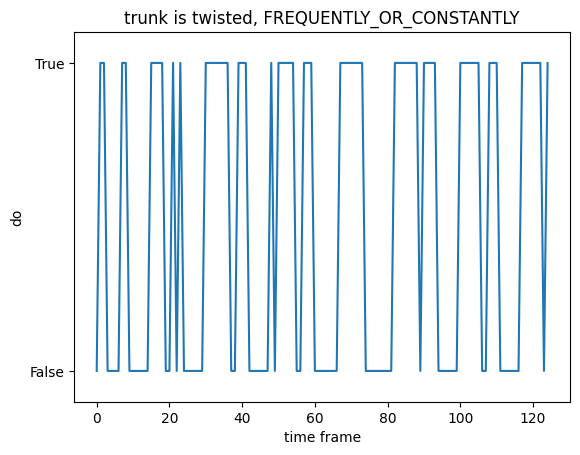

In [11]:
# 軀幹扭轉/側傾
plt.title(
    f"trunk is twisted, {lhc_analyzer.get_frequency_of_trunk_is_twisted(is_3d).name}"
)
plt.show(draw_bool_list_line_chart(lhc_analyzer.get_trunk_is_twisted_list(is_3d)))

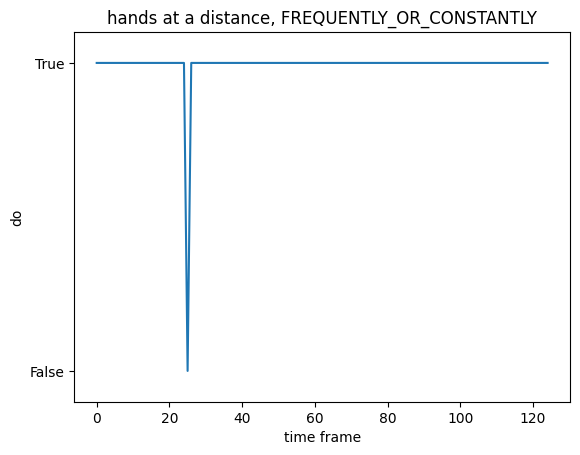

In [12]:
# 手或重心遠離身體
plt.title(
    f"hands at a distance, {lhc_analyzer.get_frequency_of_hands_at_a_distance(is_3d).name}"
)
plt.show(draw_bool_list_line_chart(lhc_analyzer.get_hands_at_a_distance_list(is_3d)))

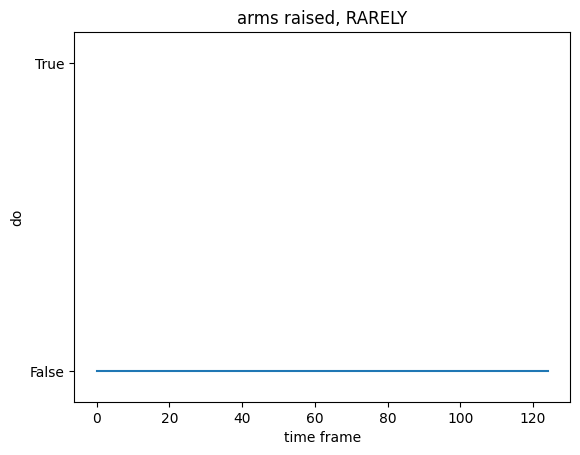

In [13]:
# 手臂抬舉，手的水平位於手肘與肩膀之間
plt.title(f"arms raised, {lhc_analyzer.get_frequency_of_arms_raised(is_3d).name}")
plt.show(draw_bool_list_line_chart(lhc_analyzer.get_arms_raised_list(is_3d)))

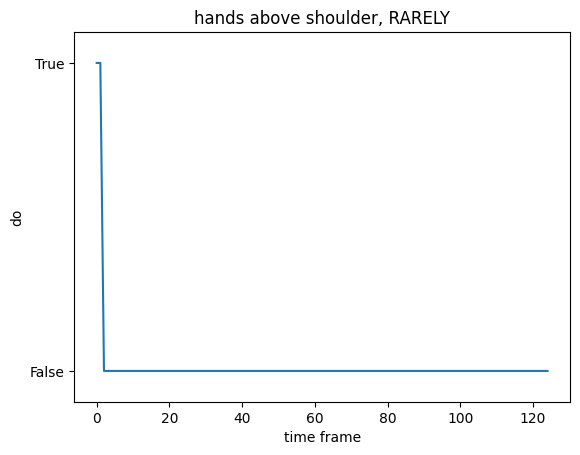

In [14]:
# 手高過肩膀
plt.title(
    f"hands above shoulder, {lhc_analyzer.get_frequency_of_hands_above_shoulder(is_3d).name}"
)
plt.show(draw_bool_list_line_chart(lhc_analyzer.get_hands_above_shoulder_list(is_3d)))